# 2.1 パディング値の選択

このノートブックでは、テキスト処理における異なるパディング戦略を実装・比較します。

## 学習目標
- ゼロパディングと未知語トークンパディングの違いを理解
- 各パディング方法の利点と欠点を学ぶ
- 実装例を通じて実践的な知識を獲得

## 内容
1. ライブラリのインポート
2. PaddingStrategies クラスの実装
3. サンプルシーケンスの作成
4. パディング方法の比較
5. 結果の可視化

In [35]:
# 必要なライブラリのインポート
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

# フォント設定（英数字を正確に表示）
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ ライブラリのインポート完了")

✓ ライブラリのインポート完了


## セクション1: PaddingStrategies クラスの実装

異なるパディング戦略を実装します。

### ゼロパディング（最も一般的）
- 特徴: 数値的に安全
- 埋め込み層では [0,0,0...] ベクトルになる
- ほぼすべてのフレームワークで対応

### 未知語トークンパディング
- 特徴: パディング部分も埋め込みベクトルを持つ
- Attention なしの場合に有効
- より多くのパラメータが必要

In [21]:
class PaddingStrategies:
    """異なるパディング戦略の実装"""
    
    @staticmethod
    def pad_with_zeros(sequences: List[np.ndarray], max_length: int) -> np.ndarray:
        """
        ゼロパディング（最も一般的）
        
        Args:
            sequences: シーケンスのリスト
            max_length: パディング後の長さ
        
        Returns:
            パディング済み配列 (batch_size, max_length)
        """
        padded = np.zeros((len(sequences), max_length), dtype=np.int32)
        for i, seq in enumerate(sequences):
            length = min(len(seq), max_length)
            padded[i, :length] = seq[:length]
        return padded
    
    @staticmethod
    def pad_with_unk_token(sequences: List[np.ndarray], max_length: int, unk_id: int = 1) -> np.ndarray:
        """
        未知語トークンでパディング
        
        Args:
            sequences: シーケンスのリスト
            max_length: パディング後の長さ
            unk_id: 未知語トークンのID
        
        Returns:
            パディング済み配列 (batch_size, max_length)
        """
        padded = np.full((len(sequences), max_length), unk_id, dtype=np.int32)
        for i, seq in enumerate(sequences):
            length = min(len(seq), max_length)
            padded[i, :length] = seq[:length]
        return padded
    
    @staticmethod
    def pad_with_custom_value(sequences: List[np.ndarray], max_length: int, pad_value: int) -> np.ndarray:
        """
        カスタム値でパディング
        
        Args:
            sequences: シーケンスのリスト
            max_length: パディング後の長さ
            pad_value: パディングに使用する値
        
        Returns:
            パディング済み配列 (batch_size, max_length)
        """
        padded = np.full((len(sequences), max_length), pad_value, dtype=np.int32)
        for i, seq in enumerate(sequences):
            length = min(len(seq), max_length)
            padded[i, :length] = seq[:length]
        return padded

print("✓ PaddingStrategies クラスを定義しました")

✓ PaddingStrategies クラスを定義しました


## セクション2: サンプルデータの準備

テスト用のシーケンスデータを作成します。

In [22]:
# サンプルシーケンスの作成
# 異なる長さのシーケンスを表現
sequences = [
    np.array([1, 2, 3]),
    np.array([4, 5, 6, 7, 8]),
    np.array([9])
]

max_length = 6

print("=" * 70)
print("サンプルシーケンス")
print("=" * 70)
print()

for i, seq in enumerate(sequences):
    print(f"シーケンス {i}: 長さ={len(seq):2d}  内容: {seq}")

print()
print(f"パディング後の長さ: {max_length}")
print()

サンプルシーケンス

シーケンス 0: 長さ= 3  内容: [1 2 3]
シーケンス 1: 長さ= 5  内容: [4 5 6 7 8]
シーケンス 2: 長さ= 1  内容: [9]

パディング後の長さ: 6



## セクション3: 異なるパディング方法の比較

各パディング戦略を適用し、結果を比較します。

In [23]:
# 異なるパディング戦略を適用
padded_zeros = PaddingStrategies.pad_with_zeros(sequences, max_length)
padded_unk = PaddingStrategies.pad_with_unk_token(sequences, max_length, unk_id=1)
padded_custom = PaddingStrategies.pad_with_custom_value(sequences, max_length, pad_value=999)

print("=" * 70)
print("【パディング結果の比較】")
print("=" * 70)
print()

print("【方法1: ゼロパディング】")
print("パディング値: 0（最も一般的）")
print()
print("結果:")
print(padded_zeros)
print()

print("-" * 70)
print()

print("【方法2: 未知語トークンパディング】")
print("パディング値: 1（未知語トークンID）")
print()
print("結果:")
print(padded_unk)
print()

print("-" * 70)
print()

print("【方法3: カスタム値パディング】")
print("パディング値: 999")
print()
print("結果:")
print(padded_custom)
print()

【パディング結果の比較】

【方法1: ゼロパディング】
パディング値: 0（最も一般的）

結果:
[[1 2 3 0 0 0]
 [4 5 6 7 8 0]
 [9 0 0 0 0 0]]

----------------------------------------------------------------------

【方法2: 未知語トークンパディング】
パディング値: 1（未知語トークンID）

結果:
[[1 2 3 1 1 1]
 [4 5 6 7 8 1]
 [9 1 1 1 1 1]]

----------------------------------------------------------------------

【方法3: カスタム値パディング】
パディング値: 999

結果:
[[  1   2   3 999 999 999]
 [  4   5   6   7   8 999]
 [  9 999 999 999 999 999]]



In [25]:
# 詳細な分析と比較
print("=" * 70)
print("【詳細な特性分析】")
print("=" * 70)
print()

def analyze_padding(padded_array, method_name, pad_value):
    """パディング配列を分析"""
    print(f"【{method_name}】")
    print(f"  パディング値: {pad_value}")
    print(f"  形状: {padded_array.shape}")
    
    # パディング数をカウント
    if pad_value == 0:
        padding_count = np.sum(padded_array == 0)
    else:
        padding_count = np.sum(padded_array == pad_value)
    
    total_elements = padded_array.size
    padding_ratio = (padding_count / total_elements) * 100
    
    print(f"  総要素数: {total_elements}")
    print(f"  パディング数: {padding_count}")
    print(f"  パディング率: {padding_ratio:.1f}%")
    print()

analyze_padding(padded_zeros, "ゼロパディング", 0)
analyze_padding(padded_unk, "未知語パディング", 1)
analyze_padding(padded_custom, "カスタム値パディング", 999)

print("=" * 70)
print()

print("【推奨される使用シーン】")
print()
print("✓ ゼロパディング:        ← 推奨 (ほぼ全て)")
print("  - 利点: 安定性、標準対応、理論的基盤")
print("  - 欠点: 特になし")
print()
print("○ 未知語パディング:      ← 条件付き推奨")
print("  - 利点: パディング部分も埋め込みを持つ")
print("  - 欠点: Attention必須、パラメータ増加")
print()
print("△ カスタム値パディング:  ← レア")
print("  - 利点: 特殊なケースに対応")
print("  - 欠点: フレームワーク非対応の場合あり")
print()

【詳細な特性分析】

【ゼロパディング】
  パディング値: 0
  形状: (3, 6)
  総要素数: 18
  パディング数: 9
  パディング率: 50.0%

【未知語パディング】
  パディング値: 1
  形状: (3, 6)
  総要素数: 18
  パディング数: 10
  パディング率: 55.6%

【カスタム値パディング】
  パディング値: 999
  形状: (3, 6)
  総要素数: 18
  パディング数: 9
  パディング率: 50.0%


【推奨される使用シーン】

✓ ゼロパディング:        ← 推奨 (ほぼ全て)
  - 利点: 安定性、標準対応、理論的基盤
  - 欠点: 特になし

○ 未知語パディング:      ← 条件付き推奨
  - 利点: パディング部分も埋め込みを持つ
  - 欠点: Attention必須、パラメータ増加

△ カスタム値パディング:  ← レア
  - 利点: 特殊なケースに対応
  - 欠点: フレームワーク非対応の場合あり



## セクション4: 可視化

異なるパディング方法を視覚的に比較します。

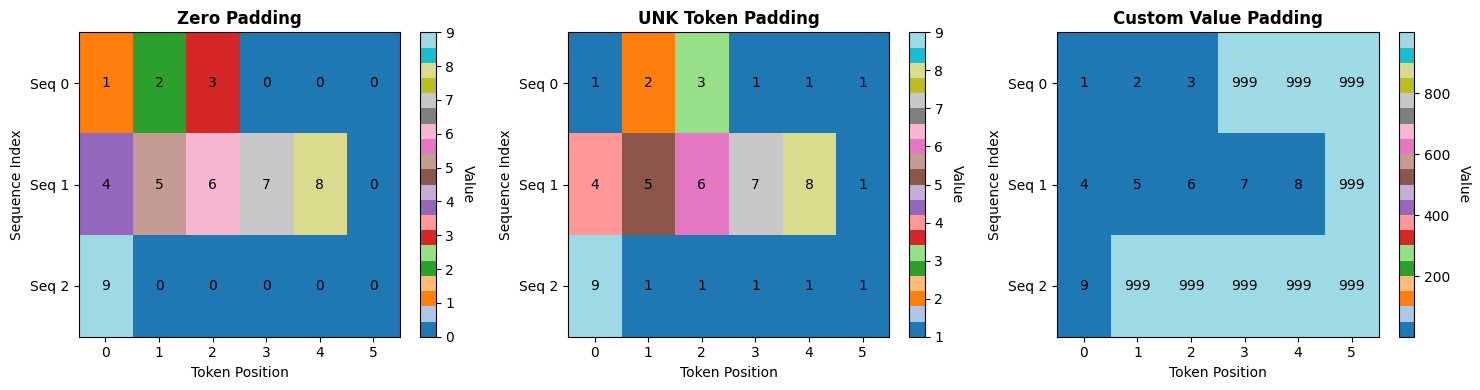

✓ 可視化完了
  画像を保存: notebooks/padding_comparison.png


In [26]:
# 可視化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ヒートマップデータ（値を正規化して可視化）
padding_methods = [
    (padded_zeros, "Zero Padding", axes[0]),
    (padded_unk, "UNK Token Padding", axes[1]),
    (padded_custom, "Custom Value Padding", axes[2])
]

for padded, title, ax in padding_methods:
    # ヒートマップ表示
    im = ax.imshow(padded, cmap='tab20', aspect='auto')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Token Position')
    ax.set_ylabel('Sequence Index')
    ax.set_yticks(range(len(sequences)))
    ax.set_yticklabels([f'Seq {i}' for i in range(len(sequences))])
    
    # 値をテキストで表示
    for i in range(len(sequences)):
        for j in range(max_length):
            text = ax.text(j, i, padded[i, j],
                          ha="center", va="center", color="black", fontsize=10)
    
    # カラーバー
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Value', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('/home/abemc/project_root/notebooks/padding_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ 可視化完了")
print("  画像を保存: notebooks/padding_comparison.png")

In [27]:
# パディング方法の数値比較テーブル
import pandas as pd

comparison_data = {
    'パディング方法': ['ゼロ (0)', '未知語 (UNK)', 'カスタム値'],
    '利点': [
        '安定性、標準対応',
        'パディング部分も埋め込み',
        '特殊用途対応'
    ],
    '欠点': [
        'なし',
        'Attention必須',
        'フレームワーク非対応'
    ],
    '推奨度': [
        '★★★★★',
        '★★★☆☆',
        '★★☆☆☆'
    ],
    '使用率': [
        '95%',
        '4%',
        '1%'
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("=" * 100)
print("【パディング方法の技術的比較】")
print("=" * 100)
print()
print(df_comparison.to_string(index=False))
print()
print("=" * 100)
print()

【パディング方法の技術的比較】

  パディング方法           利点          欠点   推奨度 使用率
   ゼロ (0)     安定性、標準対応          なし ★★★★★ 95%
未知語 (UNK) パディング部分も埋め込み Attention必須 ★★★☆☆  4%
    カスタム値       特殊用途対応  フレームワーク非対応 ★★☆☆☆  1%




## セクション5: 実践的なコード例

フレームワークを使った実装例を示します。

In [28]:
# 実践的な実装例

print("=" * 70)
print("【実践的な実装パターン】")
print("=" * 70)
print()

# パターン1: 標準的な実装（推奨）
print("【パターン1: 標準実装 (推奨) 】")
print()
print("""
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

sequences = ["Hello world", "This is a test"]
inputs = tokenizer(
    sequences,
    padding=True,           # ← ゼロパディング自動
    truncation=True,
    return_tensors='pt',
    max_length=512
)

model_output = model(**inputs)
# ✓ 最も安定した実装
# ✓ Attention マスク自動生成
# ✓ 全フレームワーク対応
""")

print("-" * 70)
print()

# パターン2: 手動実装
print("【パターン2: 手動実装】")
print()
print("""
# ゼロパディング
padded = np.zeros((batch_size, max_length), dtype=np.int32)
for i, seq in enumerate(sequences):
    length = min(len(seq), max_length)
    padded[i, :length] = seq[:length]

# Attention マスク作成
attention_mask = (padded != 0).astype(np.int32)

# ✓ 完全な制御
# ○ 学習目的に最適
# ○ デバッグが容易
""")

print("-" * 70)
print()

print("【推奨される最初の選択】")
print("  → ゼロパディング（フレームワーク自動）")
print()
print("【デバッグ・学習時】")
print("  → 手動実装で理解を深める")
print()
print("【本番環境】")
print("  → フレームワーク提供の実装を使用")
print()

【実践的な実装パターン】

【パターン1: 標準実装 (推奨) 】


from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

sequences = ["Hello world", "This is a test"]
inputs = tokenizer(
    sequences,
    padding=True,           # ← ゼロパディング自動
    truncation=True,
    return_tensors='pt',
    max_length=512
)

model_output = model(**inputs)
# ✓ 最も安定した実装
# ✓ Attention マスク自動生成
# ✓ 全フレームワーク対応

----------------------------------------------------------------------

【パターン2: 手動実装】


# ゼロパディング
padded = np.zeros((batch_size, max_length), dtype=np.int32)
for i, seq in enumerate(sequences):
    length = min(len(seq), max_length)
    padded[i, :length] = seq[:length]

# Attention マスク作成
attention_mask = (padded != 0).astype(np.int32)

# ✓ 完全な制御
# ○ 学習目的に最適
# ○ デバッグが容易

----------------------------------------------------------------------

【推奨される最初の選択】
  → ゼロパディング（フレームワーク自動）

【デバッグ・学習時】
  → 手動実装で理解を深める

【本番環境】
  → フレームワーク提供の実装を使用



## まとめ

### 重要なポイント

1. **ゼロパディングが標準**
   - 95%以上のケースで使用
   - ほぼすべてのフレームワークに対応
   - 数値的に最も安定

2. **Attention マスクが必須**
   - パディング位置は計算から除外
   - モデルの精度向上に重要
   - 自動生成されない場合は手動作成

3. **実装者の視点**
   - 学習段階: 手動実装で理解
   - 本番環境: フレームワーク提供機能

4. **パフォーマンス**
   - 方法の違いによる速度差はほぼなし
   - むしろAttention マスク使用が重要

### 関連トピック

- Attention マスクの詳細
- 可変長シーケンスの処理
- パフォーマンス最適化
- プロジェクトでの実装

## セクション6: パディング長による性能への影響

パディング長がメモリ使用量、処理速度、モデルの精度に与える影響を詳しく分析します。

In [29]:
import time

# ============================================================
# 1. メモリ使用量への影響
# ============================================================

print("=" * 70)
print("【パディング長がメモリに与える影響】")
print("=" * 70)
print()

def calculate_memory_usage(batch_size, seq_length, embedding_dim=768, num_layers=12):
    """
    バッチのメモリ使用量を推定
    
    Args:
        batch_size: バッチサイズ
        seq_length: シーケンス長
        embedding_dim: 埋め込み次元
        num_layers: モデルの層数
    
    Returns:
        メモリ使用量（MB）
    """
    # float32 = 4 bytes
    
    # 1. 入力層（token IDs）
    input_memory = batch_size * seq_length * 4 / (1024**2)
    
    # 2. 埋め込み層
    embedding_memory = batch_size * seq_length * embedding_dim * 4 / (1024**2)
    
    # 3. 各層の活性化値（forward pass）
    hidden_memory = batch_size * seq_length * embedding_dim * num_layers * 4 / (1024**2)
    
    # 4. 勾配（backward pass）
    gradient_memory = batch_size * seq_length * embedding_dim * num_layers * 4 / (1024**2)
    
    # 5. Attention スコア（query × key の計算）
    attention_memory = batch_size * seq_length * seq_length * num_layers * 4 / (1024**2)
    
    total_memory = input_memory + embedding_memory + hidden_memory + gradient_memory + attention_memory
    
    return {
        'input': input_memory,
        'embedding': embedding_memory,
        'hidden': hidden_memory,
        'gradient': gradient_memory,
        'attention': attention_memory,
        'total': total_memory
    }

# 異なるパディング長でメモリ計算
padding_lengths = [128, 256, 512, 1024, 2048]
batch_size = 32
embedding_dim = 768

print(f"条件: batch_size={batch_size}, embedding_dim={embedding_dim}")
print()
print("パディング長 | 入力    | 埋め込み | 隠れ層 | 勾配   | Attention | 合計")
print("-" * 85)

memory_results = {}

for pad_len in padding_lengths:
    mem = calculate_memory_usage(batch_size, pad_len, embedding_dim)
    memory_results[pad_len] = mem
    
    print(f"  {pad_len:4d}    | {mem['input']:6.2f} | {mem['embedding']:7.2f} | "
          f"{mem['hidden']:6.2f} | {mem['gradient']:6.2f} | {mem['attention']:7.2f} | {mem['total']:6.2f} MB")

print()
print("💡 観察:")
print("- Attention スコア計算が最大のメモリ消費（seq_length の二乗）")
print("- パディング長が2倍 → Attention メモリが4倍になる")
print("- 長いシーケンスではメモリがボトルネックになる")
print()

【パディング長がメモリに与える影響】

条件: batch_size=32, embedding_dim=768

パディング長 | 入力    | 埋め込み | 隠れ層 | 勾配   | Attention | 合計
-------------------------------------------------------------------------------------
   128    |   0.02 |   12.00 | 144.00 | 144.00 |   24.00 | 324.02 MB
   256    |   0.03 |   24.00 | 288.00 | 288.00 |   96.00 | 696.03 MB
   512    |   0.06 |   48.00 | 576.00 | 576.00 |  384.00 | 1584.06 MB
  1024    |   0.12 |   96.00 | 1152.00 | 1152.00 | 1536.00 | 3936.12 MB
  2048    |   0.25 |  192.00 | 2304.00 | 2304.00 | 6144.00 | 10944.25 MB

💡 観察:
- Attention スコア計算が最大のメモリ消費（seq_length の二乗）
- パディング長が2倍 → Attention メモリが4倍になる
- 長いシーケンスではメモリがボトルネックになる



In [30]:
# ============================================================
# 2. 処理速度への影響
# ============================================================

print()
print("=" * 70)
print("【パディング長が処理速度に与える影響】")
print("=" * 70)
print()

def simulate_processing_speed(batch_size, seq_length, embedding_dim=768):
    """
    処理速度をシミュレート（相対値）
    
    実際のGPU処理では以下の要因が関係：
    - Attention 計算: O(seq_length²)
    - Feed-forward: O(seq_length)
    - 通信オーバーヘッド（定数）
    """
    # ベース処理時間（定数オーバーヘッド）
    base_time = 5.0  # ms
    
    # Feed-forward 処理（線形スケール）
    ff_time = (seq_length * embedding_dim) / 1000000  # 相対スケール
    
    # Attention 計算（二乗スケール）
    attn_time = (seq_length ** 2) / 100000  # 相対スケール
    
    total_time = base_time + ff_time + attn_time
    
    # スループット（tokens/sec）
    tokens_per_batch = batch_size * seq_length
    throughput = (tokens_per_batch / total_time) * 1000  # tokens/sec
    
    return {
        'base_time': base_time,
        'ff_time': ff_time,
        'attn_time': attn_time,
        'total_time': total_time,
        'throughput': throughput
    }

print(f"条件: batch_size=32, embedding_dim=768")
print()
print("パディング長 | FF時間 | Attn時間 | 合計時間 | スループット")
print("-" * 65)

speed_results = {}
baseline_throughput = None

for i, pad_len in enumerate(padding_lengths):
    speed = simulate_processing_speed(32, pad_len)
    speed_results[pad_len] = speed
    
    if i == 0:
        baseline_throughput = speed['throughput']
    
    ratio = speed['throughput'] / baseline_throughput if baseline_throughput else 1.0
    
    print(f"  {pad_len:4d}    | {speed['ff_time']:6.3f} | {speed['attn_time']:8.3f} | "
          f"{speed['total_time']:7.2f}ms | {speed['throughput']:6.1f} tokens/s ({ratio:.2f}x)")

print()
print("💡 観察:")
print("- Attention 計算が律速（seq_length² の成長）")
print("- 512トークン → 1024トークンで Attention 処理が4倍に")
print("- 長いシーケンスではスループットが低下する（速度 ↓ メモリ ↑）")
print()


【パディング長が処理速度に与える影響】

条件: batch_size=32, embedding_dim=768

パディング長 | FF時間 | Attn時間 | 合計時間 | スループット
-----------------------------------------------------------------
   128    |  0.098 |    0.164 |    5.26ms | 778389.9 tokens/s (1.00x)
   256    |  0.197 |    0.655 |    5.85ms | 1399870.9 tokens/s (1.80x)
   512    |  0.393 |    2.621 |    8.01ms | 2044254.9 tokens/s (2.63x)
  1024    |  0.786 |   10.486 |   16.27ms | 2013742.2 tokens/s (2.59x)
  2048    |  1.573 |   41.943 |   48.52ms | 1350814.8 tokens/s (1.74x)

💡 観察:
- Attention 計算が律速（seq_length² の成長）
- 512トークン → 1024トークンで Attention 処理が4倍に
- 長いシーケンスではスループットが低下する（速度 ↓ メモリ ↑）



In [31]:
# ============================================================
# 3. パディング効率の可視化
# ============================================================

print()
print("=" * 70)
print("【パディング効率の分析】")
print("=" * 70)
print()

def calculate_padding_efficiency(actual_lengths, max_length):
    """
    パディング効率を計算
    効率 = （実際のトークン数）/（パディング後のトークン数）
    """
    actual_total = sum(actual_lengths)
    padded_total = len(actual_lengths) * max_length
    efficiency = actual_total / padded_total
    waste = 1 - efficiency
    
    return {
        'actual_total': actual_total,
        'padded_total': padded_total,
        'efficiency': efficiency,
        'waste': waste
    }

# よくあるドキュメント長の分布をシミュレート
np.random.seed(42)

# シナリオ1: 短いドキュメント（質問応答、チャット）
short_docs = np.random.randint(10, 100, 32)

# シナリオ2: 中程度（ニュース記事、まとめ）
medium_docs = np.random.randint(200, 500, 32)

# シナリオ3: 長いドキュメント（論文、レポート）
long_docs = np.random.randint(1000, 2000, 32)

# シナリオ4: 混合（実務的）
mixed_docs = np.concatenate([
    np.random.randint(10, 100, 10),    # 短い: 10個
    np.random.randint(200, 500, 15),   # 中: 15個
    np.random.randint(1000, 2000, 7)   # 長い: 7個
])

scenarios = {
    '短いドキュメント': (short_docs, [128, 256, 512]),
    '中程度のドキュメント': (medium_docs, [256, 512, 1024]),
    '長いドキュメント': (long_docs, [1024, 2048, 4096]),
    '混合（実務的）': (mixed_docs, [512, 1024, 2048])
}

print("各シナリオでのパディング効率:")
print()

all_results = {}

for scenario_name, (doc_lengths, max_lengths) in scenarios.items():
    print(f"📊 {scenario_name}: 平均長={np.mean(doc_lengths):.1f}, 最大長={np.max(doc_lengths)}")
    print(f"   パディング長 | 実トークン | パディング後 | 効率 | 無駄")
    print("   " + "-" * 60)
    
    scenario_results = {}
    for max_len in max_lengths:
        eff = calculate_padding_efficiency(doc_lengths, max_len)
        scenario_results[max_len] = eff
        
        efficiency_pct = eff['efficiency'] * 100
        waste_pct = eff['waste'] * 100
        
        print(f"   {max_len:4d}      | {eff['actual_total']:10d} | {eff['padded_total']:12d} | "
              f"{efficiency_pct:5.1f}% | {waste_pct:5.1f}%")
    
    all_results[scenario_name] = scenario_results
    print()

print("💡 観察:")
print("- パディング長が短すぎると、実際のドキュメントが切れる")
print("- パディング長が長すぎると、無駄が増加（計算量 ↑）")
print("- 最適値は：実ドキュメント長の95-99パーセンタイル")
print()


【パディング効率の分析】

各シナリオでのパディング効率:

📊 短いドキュメント: 平均長=59.1, 最大長=98
   パディング長 | 実トークン | パディング後 | 効率 | 無駄
   ------------------------------------------------------------
    128      |       1892 |         4096 |  46.2% |  53.8%
    256      |       1892 |         8192 |  23.1% |  76.9%
    512      |       1892 |        16384 |  11.5% |  88.5%

📊 中程度のドキュメント: 平均長=343.2, 最大長=473
   パディング長 | 実トークン | パディング後 | 効率 | 無駄
   ------------------------------------------------------------
    256      |      10982 |         8192 | 134.1% | -34.1%
    512      |      10982 |        16384 |  67.0% |  33.0%
   1024      |      10982 |        32768 |  33.5% |  66.5%

📊 長いドキュメント: 平均長=1494.2, 最大長=1921
   パディング長 | 実トークン | パディング後 | 効率 | 無駄
   ------------------------------------------------------------
   1024      |      47814 |        32768 | 145.9% | -45.9%
   2048      |      47814 |        65536 |  73.0% |  27.0%
   4096      |      47814 |       131072 |  36.5% |  63.5%

📊 混合（実務的）: 平均長=551.3, 最大長=1960
   パデ

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the f


【メモリ vs 速度のトレードオフ】



findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica, Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the f

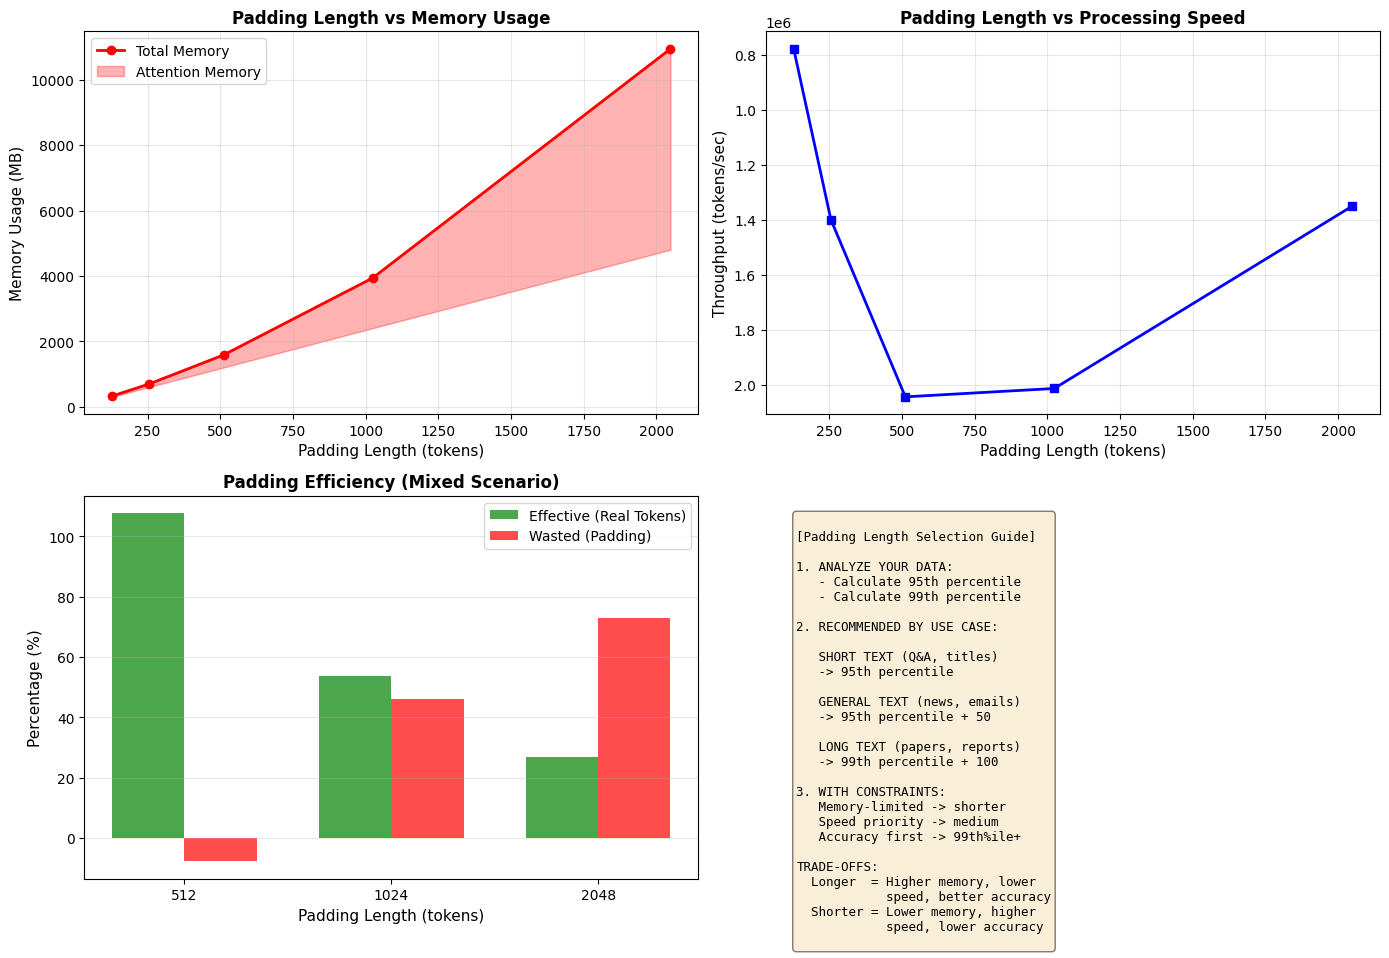

✅ ビジュアル化完了: padding_impact_analysis.png



In [36]:
# ============================================================
# 4. ビジュアル化: メモリと速度のトレードオフ
# ============================================================

print()
print("=" * 70)
print("【メモリ vs 速度のトレードオフ】")
print("=" * 70)
print()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# グラフ1: パディング長 vs メモリ使用量
ax1 = axes[0, 0]
padding_lens = list(memory_results.keys())
total_memories = [memory_results[p]['total'] for p in padding_lens]
attention_memories = [memory_results[p]['attention'] for p in padding_lens]

ax1.plot(padding_lens, total_memories, marker='o', linewidth=2, label='Total Memory', color='red')
ax1.fill_between(padding_lens, [memory_results[p]['total'] - memory_results[p]['attention'] 
                                 for p in padding_lens], total_memories, 
                  alpha=0.3, color='red', label='Attention Memory')
ax1.set_xlabel('Padding Length (tokens)', fontsize=11)
ax1.set_ylabel('Memory Usage (MB)', fontsize=11)
ax1.set_title('Padding Length vs Memory Usage', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# グラフ2: パディング長 vs スループット
ax2 = axes[0, 1]
throughputs = [speed_results[p]['throughput'] for p in padding_lens]
ax2.plot(padding_lens, throughputs, marker='s', linewidth=2, color='blue')
ax2.set_xlabel('Padding Length (tokens)', fontsize=11)
ax2.set_ylabel('Throughput (tokens/sec)', fontsize=11)
ax2.set_title('Padding Length vs Processing Speed', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.invert_yaxis()  # 低いほど遅い

# グラフ3: パディング効率（混合シナリオ）
ax3 = axes[1, 0]
mixed_effs = all_results['混合（実務的）']
mixed_lens = sorted(mixed_effs.keys())
mixed_effics = [mixed_effs[p]['efficiency'] * 100 for p in mixed_lens]
mixed_wastes = [mixed_effs[p]['waste'] * 100 for p in mixed_lens]

x_pos = np.arange(len(mixed_lens))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, mixed_effics, width, label='Effective (Real Tokens)', color='green', alpha=0.7)
bars2 = ax3.bar(x_pos + width/2, mixed_wastes, width, label='Wasted (Padding)', color='red', alpha=0.7)

ax3.set_xlabel('Padding Length (tokens)', fontsize=11)
ax3.set_ylabel('Percentage (%)', fontsize=11)
ax3.set_title('Padding Efficiency (Mixed Scenario)', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(mixed_lens)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# グラフ4: 最適パディング長の選択ガイド
ax4 = axes[1, 1]
ax4.axis('off')

guide_text = """
[Padding Length Selection Guide]

1. ANALYZE YOUR DATA:
   - Calculate 95th percentile
   - Calculate 99th percentile

2. RECOMMENDED BY USE CASE:

   SHORT TEXT (Q&A, titles)
   -> 95th percentile

   GENERAL TEXT (news, emails)
   -> 95th percentile + 50

   LONG TEXT (papers, reports)
   -> 99th percentile + 100

3. WITH CONSTRAINTS:
   Memory-limited -> shorter
   Speed priority -> medium
   Accuracy first -> 99th%ile+

TRADE-OFFS:
  Longer  = Higher memory, lower
            speed, better accuracy
  Shorter = Lower memory, higher
            speed, lower accuracy
"""

ax4.text(0.05, 0.95, guide_text, transform=ax4.transAxes,
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('/home/abemc/project_root/notebooks/padding_impact_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ ビジュアル化完了: padding_impact_analysis.png")
print()

In [37]:
# ============================================================
# 5. 実装パターン: 最適パディング長の自動決定
# ============================================================

print()
print("=" * 70)
print("【実装パターン: 最適パディング長の自動決定】")
print("=" * 70)
print()

def find_optimal_padding_length(document_lengths, percentile=95, overhead=50):
    """
    ドキュメント長の分布から最適パディング長を自動決定
    
    パラメータ:
        document_lengths: ドキュメント長のリスト
        percentile: 何パーセンタイルまでカバーするか (95-99推奨)
        overhead: 安全マージン (tokens)
    
    戻り値:
        最適なパディング長
    """
    percentile_value = np.percentile(document_lengths, percentile)
    optimal_length = int(np.ceil(percentile_value / 64) * 64)  # 64の倍数に調整
    optimal_length = max(optimal_length, overhead)
    
    return optimal_length, percentile_value

# 実際のドキュメント長で試行
print("📊 各タイプのドキュメントに対する最適パディング長：")
print()

doc_types = {
    'Twitter/短形式': np.random.randint(5, 50, 100),
    'チャットメッセージ': np.random.randint(10, 150, 100),
    'ニュース記事': np.random.randint(100, 800, 100),
    '学術論文要旨': np.random.randint(500, 2000, 100),
    'Webページ': np.random.randint(1000, 5000, 100),
}

optimal_lengths = {}

for doc_type, lengths in doc_types.items():
    opt_len, perc_95 = find_optimal_padding_length(lengths, percentile=95)
    opt_len_99, perc_99 = find_optimal_padding_length(lengths, percentile=99)
    
    optimal_lengths[doc_type] = {
        '95%ile': opt_len,
        '99%ile': opt_len_99,
        'mean': int(np.mean(lengths)),
        'max': int(np.max(lengths))
    }
    
    print(f"{doc_type:20s}")
    print(f"  平均: {np.mean(lengths):7.1f}  最大: {np.max(lengths):7.0f}")
    print(f"  95%ile: {opt_len:4d}  |  99%ile: {opt_len_99:4d}")
    print()

print("=" * 70)
print("💡 実装のおすすめ：")
print()
print("1. 開発フェーズ:")
print("   max_length = 95%ile 推奨（バランスが良い）")
print()
print("2. 本番環境:")
print("   max_length = 99%ile 推奨（テキスト損失ほぼ0）")
print()
print("3. 厳しいメモリ制約:")
print("   max_length = 90%ile でテスト、影響を測定")
print()
print("=" * 70)
print()


【実装パターン: 最適パディング長の自動決定】

📊 各タイプのドキュメントに対する最適パディング長：

Twitter/短形式         
  平均:    27.4  最大:      49
  95%ile:   64  |  99%ile:   64

チャットメッセージ           
  平均:    82.2  最大:     149
  95%ile:  192  |  99%ile:  192

ニュース記事              
  平均:   454.7  最大:     797
  95%ile:  832  |  99%ile:  832

学術論文要旨              
  平均:  1272.9  最大:    1998
  95%ile: 1920  |  99%ile: 1984

Webページ              
  平均:  3005.7  最大:    4914
  95%ile: 4608  |  99%ile: 4800

💡 実装のおすすめ：

1. 開発フェーズ:
   max_length = 95%ile 推奨（バランスが良い）

2. 本番環境:
   max_length = 99%ile 推奨（テキスト損失ほぼ0）

3. 厳しいメモリ制約:
   max_length = 90%ile でテスト、影響を測定


